In [ ]:
import sys, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path
from chronos import ChronosPipeline

sys.path.insert(0, str(Path('..') / 'timesfm_google'))
from benchmark.forecasters.naive       import NaiveBenchmarkForecaster
from benchmark.forecasters.arima       import ARIMAForecaster
from benchmark.forecasters.auto_arima  import AutoARIMAForecaster
from benchmark.forecasters.bayesian_ar import BayesianARForecaster
from benchmark.forecasters.ml_bayes_ar import MLBayesARForecaster
from benchmark.forecasters.ssa         import SSAForecaster
from benchmark.forecasters.ar_garch    import ARGARCHForecaster

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Imports OK")


Imports OK


In [ ]:
HORIZON         = 1
CHRONOS_CONTEXT = 512
CHRONOS_MODEL   = 'amazon/chronos-t5-tiny'  # swap small/base for higher quality
MAX_OOS_ORIGINS = 500
ROLLING_WINDOW  = 36

DATA_DIR    = Path('data')
RESULTS_DIR = Path('results')

# Set RUN_DATASETS = None to run all 6 datasets.
RUN_DATASETS = ['FEDFUNDS','GS10','UNRATE']

DATASETS = [
    dict(name='FEDFUNDS', path='data/FEDFUNDS.csv', date_col='observation_date', target_col='FEDFUNDS', k_first=360),
    dict(name='GS10',     path='data/GS10.csv',     date_col='observation_date', target_col='GS10',     k_first=360),
    dict(name='UNRATE',   path='data/UNRATE.csv',   date_col='observation_date', target_col='UNRATE',   k_first=360),
    dict(name='T10Y2Y',   path='data/T10Y2Y.csv',   date_col='observation_date', target_col='T10Y2Y',   k_first=512),
    dict(name='DGS10',    path='data/DGS10.csv',    date_col='observation_date', target_col='DGS10',    k_first=512),
    dict(name='VIXCLS',   path='data/VIXCLS.csv',   date_col='observation_date', target_col='VIXCLS',   k_first=512),
]

# Full colour registry — add entries here if you add new models
COLORS = {
    'Chronos'  : 'steelblue',
    'Naive'    : 'gray',
    'AR(1)'    : 'green',
    'AutoARIMA': 'darkorange',
    'BayesAR'  : 'purple',
    'MLBayesAR': 'crimson',
    'SSA'      : 'saddlebrown',
    'AR-GARCH' : 'teal',
}


: 

In [ ]:
# ┌─────────────────────────────────────────────────────────────────┐
# │  MODEL SELECTION — comment out any line to drop that model      │
# └─────────────────────────────────────────────────────────────────┘

RUN_CHRONOS = True   # set False to skip the Chronos-T5 pipeline entirely

def make_baselines():
    return {
        'Naive'    : NaiveBenchmarkForecaster(),
        # 'AR(1)'    : ARIMAForecaster(order=(1, 0, 0)),
        'AutoARIMA': AutoARIMAForecaster(p_max=4, q_max=2, d_max=2),
        'BayesAR'  : BayesianARForecaster(p=3, prior_mode='ridge'),
        'MLBayesAR': MLBayesARForecaster(p=24, prior_mode='minnesota'),
        # 'SSA'      : SSAForecaster(),
        # 'AR-GARCH' : ARGARCHForecaster(p=1),
    }

# MODEL_NAMES is derived automatically — do not edit manually
_probe      = make_baselines()
MODEL_NAMES = (['Chronos'] if RUN_CHRONOS else []) + list(_probe.keys())
del _probe
print(f"Active models: {MODEL_NAMES}")


Active models: ['Chronos', 'Naive', 'BayesAR', 'MLBayesAR']


: 

In [ ]:
(RESULTS_DIR / 'plots').mkdir(parents=True, exist_ok=True)
print(f"Results dir: {RESULTS_DIR.resolve()}")


Results dir: /Users/nikhileshbelulkar/Documents/TSF_models/granite-tsfm/results


: 

In [ ]:
if RUN_CHRONOS:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    dtype  = torch.bfloat16 if device == 'cuda' else torch.float32
    pipeline = ChronosPipeline.from_pretrained(
        CHRONOS_MODEL, device_map=device, torch_dtype=dtype,
    )
    print(f"Loaded {CHRONOS_MODEL} on {device}")
else:
    pipeline = None
    print("Chronos skipped (RUN_CHRONOS = False)")


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded amazon/chronos-t5-tiny on cpu


: 

In [ ]:
def chronos_predict_one_step(pipeline, history_values):
    ctx = history_values[-CHRONOS_CONTEXT:] if len(history_values) > CHRONOS_CONTEXT else history_values
    context = torch.tensor(np.array(ctx, dtype=np.float32))
    forecast = pipeline.predict(context, prediction_length=1)
    samples = forecast[0, :, 0].detach().cpu().numpy()
    return (
        float(np.quantile(samples, 0.50)),
        float(np.quantile(samples, 0.10)),
        float(np.quantile(samples, 0.90)),
    )


def compute_metrics(preds, actuals, lowers=None, uppers=None):
    p, a = np.array(preds, dtype=float), np.array(actuals, dtype=float)
    mask = ~np.isnan(p)
    e = p[mask] - a[mask]
    result = dict(
        n_forecasts=int(mask.sum()),
        mse=float(np.mean(e**2)),
        rmse=float(np.sqrt(np.mean(e**2))),
        mae=float(np.mean(np.abs(e))),
        coverage_80=float('nan'),
        avg_interval_width=float('nan'),
    )
    if lowers is not None and uppers is not None:
        lo = np.array(lowers, dtype=float)
        hi = np.array(uppers, dtype=float)
        im = mask & ~np.isnan(lo) & ~np.isnan(hi)
        if im.sum() > 0:
            result['coverage_80']        = float(np.mean((lo[im] <= a[im]) & (a[im] <= hi[im])))
            result['avg_interval_width'] = float(np.mean(hi[im] - lo[im]))
    return result


def rolling_mean(x, w):
    return pd.Series(np.array(x, dtype=float)).rolling(w, min_periods=1).mean().values


: 

In [ ]:
import time

all_metrics_rows  = []
all_forecast_rows = []
all_failure_rows  = []
dataset_results   = {}

active_datasets = [ds for ds in DATASETS
                   if RUN_DATASETS is None or ds['name'] in RUN_DATASETS]

for ds in active_datasets:
    t_ds_start = time.time()
    print(f"\n{'='*60}")
    print(f"Dataset: {ds['name']}")

    df = pd.read_csv(ds['path'], parse_dates=[ds['date_col']])
    df[ds['target_col']] = pd.to_numeric(df[ds['target_col']], errors='coerce')
    df = (df[[ds['date_col'], ds['target_col']]]
            .dropna()
            .sort_values(ds['date_col'])
            .reset_index(drop=True))
    values = df[ds['target_col']].values.astype(float)
    dates  = df[ds['date_col']].values
    n      = len(df)
    print(f"  Rows after cleaning: {n}")

    origins = list(range(ds['k_first'], n))
    if len(origins) > MAX_OOS_ORIGINS:
        origins = origins[-MAX_OOS_ORIGINS:]
    print(f"  OOS origins: {len(origins)}  (t={origins[0]} .. {origins[-1]})")

    baselines = make_baselines()

    preds_ds  = {m: [] for m in MODEL_NAMES}
    lowers_ds = {m: [] for m in MODEL_NAMES}
    uppers_ds = {m: [] for m in MODEL_NAMES}
    actuals_ds = []
    dates_oos  = []

    for t in tqdm(origins, desc=ds['name']):
        history = values[:t]
        y_true  = values[t]
        actuals_ds.append(y_true)
        dates_oos.append(dates[t])

        if RUN_CHRONOS:
            try:
                p_c, lo_c, hi_c = chronos_predict_one_step(pipeline, history)
            except Exception as ex:
                all_failure_rows.append(dict(dataset=ds['name'], model='Chronos', error_message=str(ex)))
                p_c, lo_c, hi_c = float('nan'), float('nan'), float('nan')
            preds_ds['Chronos'].append(p_c)
            lowers_ds['Chronos'].append(lo_c)
            uppers_ds['Chronos'].append(hi_c)

        for name, fc in baselines.items():
            if name not in MODEL_NAMES:
                continue
            try:
                fc.fit(history)
                p_fc = float(fc.predict(1)[0])
                try:
                    lo_arr, hi_arr = fc.predict_quantiles(1)
                    lo_fc, hi_fc = float(lo_arr[0]), float(hi_arr[0])
                except (AttributeError, NotImplementedError):
                    lo_fc, hi_fc = float('nan'), float('nan')
            except Exception as ex:
                all_failure_rows.append(dict(dataset=ds['name'], model=name, error_message=str(ex)))
                p_fc, lo_fc, hi_fc = float('nan'), float('nan'), float('nan')
            preds_ds[name].append(p_fc)
            lowers_ds[name].append(lo_fc)
            uppers_ds[name].append(hi_fc)

        for model in MODEL_NAMES:
            all_forecast_rows.append(dict(
                dataset=ds['name'], date=dates[t], model=model,
                y_true=y_true,
                y_pred=preds_ds[model][-1],
                lower_80=lowers_ds[model][-1],
                upper_80=uppers_ds[model][-1],
            ))

    naive_rmse = compute_metrics(preds_ds['Naive'], actuals_ds)['rmse']
    for model in MODEL_NAMES:
        m = compute_metrics(preds_ds[model], actuals_ds, lowers_ds[model], uppers_ds[model])
        m['rmse_over_naive'] = m['rmse'] / naive_rmse if naive_rmse > 0 else float('nan')
        m['dataset'] = ds['name']
        m['model']   = model
        all_metrics_rows.append(m)

    dataset_results[ds['name']] = dict(
        actuals=np.array(actuals_ds),
        preds=preds_ds, lowers=lowers_ds, uppers=uppers_ds, dates=dates_oos,
    )

    elapsed = time.time() - t_ds_start
    print(f"  Done: {len(origins)} origins in {elapsed:.1f}s  ({elapsed/len(origins):.2f}s/origin)")

print("\nAll datasets complete.")



Dataset: FEDFUNDS
  Rows after cleaning: 861
  OOS origins: 500  (t=361 .. 860)


FEDFUNDS:   0%|          | 0/500 [00:00<?, ?it/s]

  Done: 500 origins in 39.9s  (0.08s/origin)

All datasets complete.


: 

In [ ]:
METRICS_COLS = ['dataset', 'model', 'n_forecasts', 'mse', 'rmse', 'mae',
                'rmse_over_naive', 'coverage_80', 'avg_interval_width']

metrics_df = pd.DataFrame(all_metrics_rows)[METRICS_COLS]
metrics_df.to_csv(RESULTS_DIR / 'metrics_summary.csv', index=False)
print(f"Saved metrics_summary.csv  ({len(metrics_df)} rows)")

pd.DataFrame(all_forecast_rows).to_parquet(RESULTS_DIR / 'forecast_records.parquet', index=False)
print(f"Saved forecast_records.parquet")

failures_df = (pd.DataFrame(all_failure_rows) if all_failure_rows
               else pd.DataFrame(columns=['dataset', 'model', 'error_message']))
failures_df.to_csv(RESULTS_DIR / 'model_failures.csv', index=False)
print(f"Saved model_failures.csv  ({len(failures_df)} failures)")

print("\nMetrics summary:")
display(metrics_df)


Saved metrics_summary.csv  (4 rows)
Saved forecast_records.parquet
Saved model_failures.csv  (0 failures)

Metrics summary:


,dataset,model,n_forecasts,mse,rmse,mae,rmse_over_naive,coverage_80,avg_interval_width
0,FEDFUNDS,Chronos,500,0.037301,0.193136,0.114628,0.904732,0.628,0.297459
1,FEDFUNDS,Naive,500,0.045571,0.213473,0.124380,1.000000,0.010,2.718272
2,FEDFUNDS,BayesAR,500,0.035130,0.187429,0.112499,0.878000,0.010,2.758774
3,FEDFUNDS,MLBayesAR,500,0.037901,0.194682,0.120932,0.911975,0.010,2.783979


: 

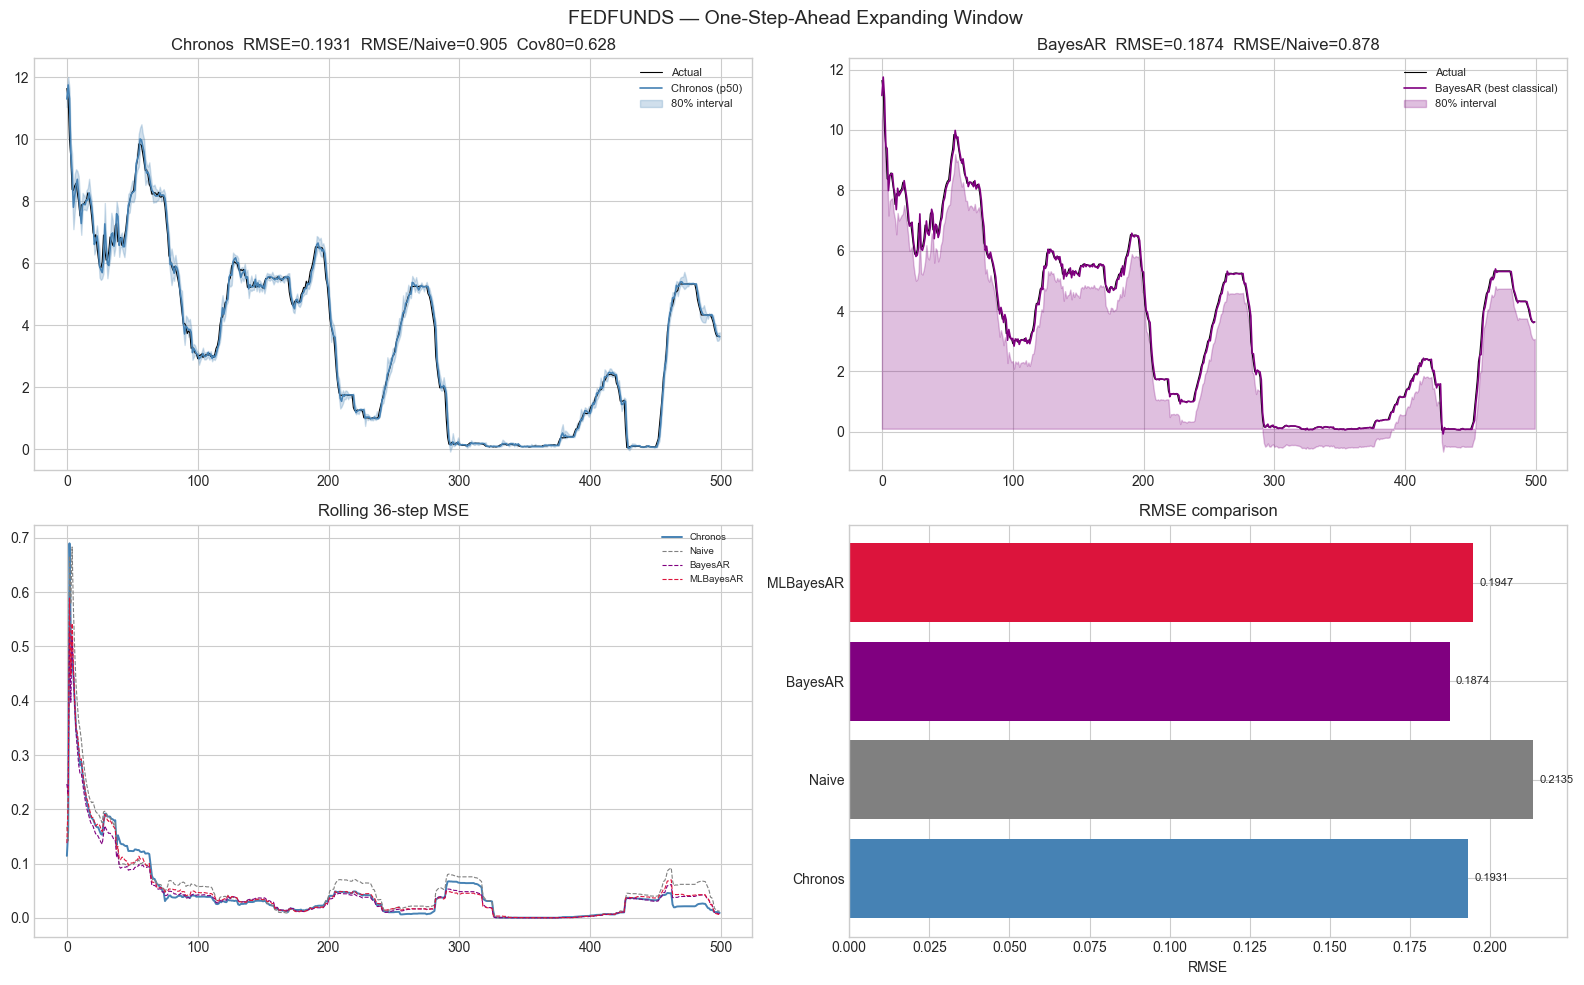

Saved results/plots/FEDFUNDS_benchmark.png


: 

In [ ]:
for ds_name, res in dataset_results.items():
    actuals = res['actuals']
    preds   = res['preds']
    lowers  = res['lowers']
    uppers  = res['uppers']
    idx     = np.arange(len(actuals))

    ds_metrics = {r['model']: r for r in all_metrics_rows if r['dataset'] == ds_name}
    classical_names = [m for m in MODEL_NAMES if m != 'Chronos']
    best_classical  = min(classical_names, key=lambda m: ds_metrics[m].get('rmse', float('inf')))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{ds_name} — One-Step-Ahead Expanding Window', fontsize=14)

    # Actual vs Chronos + interval
    ax = axes[0, 0]
    ax.plot(idx, actuals, 'k', lw=0.8, label='Actual')
    if RUN_CHRONOS:
        ax.plot(idx, preds['Chronos'], color=COLORS['Chronos'], lw=1.2, label='Chronos (p50)')
        lo_c = np.array(lowers['Chronos'], dtype=float)
        hi_c = np.array(uppers['Chronos'], dtype=float)
        ax.fill_between(idx, lo_c, hi_c, color=COLORS['Chronos'], alpha=0.25, label='80% interval')
        cm = ds_metrics['Chronos']
        ax.set_title(f"Chronos  RMSE={cm['rmse']:.4f}  RMSE/Naive={cm['rmse_over_naive']:.3f}  Cov80={cm['coverage_80']:.3f}")
    else:
        ax.set_title('Chronos (disabled)')
    ax.legend(fontsize=8); ax.grid(True)

    # Actual vs best classical + interval
    ax = axes[0, 1]
    ax.plot(idx, actuals, 'k', lw=0.8, label='Actual')
    ax.plot(idx, preds[best_classical], color=COLORS[best_classical], lw=1.2,
            label=f'{best_classical} (best classical)')
    lo_b = np.array(lowers[best_classical], dtype=float)
    hi_b = np.array(uppers[best_classical], dtype=float)
    if not np.all(np.isnan(lo_b)):
        ax.fill_between(idx, lo_b, hi_b, color=COLORS[best_classical], alpha=0.25, label='80% interval')
    bm = ds_metrics[best_classical]
    ax.set_title(f"{best_classical}  RMSE={bm['rmse']:.4f}  RMSE/Naive={bm['rmse_over_naive']:.3f}")
    ax.legend(fontsize=8); ax.grid(True)

    # Rolling MSE
    ax = axes[1, 0]
    for model in MODEL_NAMES:
        se = (np.array(preds[model], dtype=float) - actuals) ** 2
        ax.plot(rolling_mean(se, ROLLING_WINDOW), color=COLORS[model],
                lw=1.4 if model == 'Chronos' else 0.8,
                ls='-'  if model == 'Chronos' else '--', label=model)
    ax.set_title(f'Rolling {ROLLING_WINDOW}-step MSE')
    ax.legend(fontsize=7); ax.grid(True)

    # RMSE bar chart
    ax = axes[1, 1]
    rmse_vals = [ds_metrics[m]['rmse'] for m in MODEL_NAMES]
    bars = ax.barh(MODEL_NAMES, rmse_vals, color=[COLORS[m] for m in MODEL_NAMES])
    ax.set_title('RMSE comparison'); ax.set_xlabel('RMSE'); ax.grid(True, axis='x')
    for bar, val in zip(bars, rmse_vals):
        ax.text(val * 1.01, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    save_path = RESULTS_DIR / 'plots' / f'{ds_name}_benchmark.png'
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved {save_path}")


In [ ]:
if len(dataset_results) > 1:
    summary  = metrics_df.pivot(index='model', columns='dataset', values='rmse_over_naive')
    ds_names = list(dataset_results.keys())
    x, width = np.arange(len(ds_names)), 0.8 / len(MODEL_NAMES)
    fig, ax = plt.subplots(figsize=(max(8, len(ds_names) * 2), 5))
    for i, model in enumerate(MODEL_NAMES):
        vals = [summary.loc[model, d] if d in summary.columns else float('nan') for d in ds_names]
        ax.bar(x + i * width, vals, width, label=model, color=COLORS[model])
    ax.axhline(1.0, color='black', ls='--', lw=1, label='Naive = 1.0')
    ax.set_xticks(x + width * (len(MODEL_NAMES) - 1) / 2)
    ax.set_xticklabels(ds_names)
    ax.set_ylabel('RMSE / Naive RMSE')
    ax.set_title('Cross-dataset: RMSE relative to Naive')
    ax.legend(fontsize=7); ax.grid(True, axis='y')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'plots' / 'cross_dataset_summary.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    ds_name = list(dataset_results.keys())[0]
    display(metrics_df[metrics_df['dataset'] == ds_name]
            [['model', 'rmse', 'rmse_over_naive', 'coverage_80', 'avg_interval_width']]
            .sort_values('rmse').reset_index(drop=True))


,model,rmse,rmse_over_naive,coverage_80,avg_interval_width
0,BayesAR,0.187429,0.878000,0.010,2.758774
1,Chronos,0.193136,0.904732,0.628,0.297459
2,MLBayesAR,0.194682,0.911975,0.010,2.783979
3,Naive,0.213473,1.000000,0.010,2.718272


: 